In [1]:
#import the necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

First, we upload the data and take a look at it:

In [2]:
url = "https://raw.githubusercontent.com/ust-buan-640/buan-640-notebooks/main/data/data-of-homes-s26.csv"

df = pd.read_csv(url)

print(df.head()) #take a look at the data frame


   zip_listings_total  k  m    zip capture_timestamp  \
0                  73  2  2  55124        2026-02-04   
1                  73  2  2  55124        2026-02-04   
2                  73  2  2  55124        2026-02-04   
3                  73  2  2  55124        2026-02-04   
4                  73  2  2  55124        2026-02-04   

                                                 url  \
0  https://www.zillow.com/homedetails/13937-Ember...   
1  https://www.zillow.com/homedetails/14217-Footb...   
2  https://www.zillow.com/homedetails/15579-Duck-...   
3  https://www.zillow.com/homedetails/12439-Drayt...   
4  https://www.zillow.com/homedetails/13850-Penno...   

                              address       status  list_price  beds  baths  \
0        13937 Ember Ct. Apple valley     For Sale    999900.0     5      4   
1  14217 Footbridge Way, Apple Valley     For Sale    715000.0     4      4   
2                 15579 Duck Trail Ln     For Sale    700000.0     4      4   
3     1243

If you go through the entire file, you will note that not all the dates are displayed correctly, and there are still some other problems in the data (but I fixed the most problematic mistakes to get the job easier for you!)

How many observations we have? To count the number of rows (excluding the header), we use function len

In [ ]:
nobs = len(df)
print("The number of observation is nobs = ", nobs)

The number of observation is nobs =  113


In [ ]:
df["property_type"].value_counts(dropna=False)

property_type
Single Family Residence    77
Townhouse                  25
Condo                       6
Twin Home                   2
Low Rise                    2
Townhouse Detached          1
Name: count, dtype: int64

Above you see the tally of the property types recorded here. Note that due to the data entry problems there are some inconsistensies. We should have had only three types: Condo, Townhouse, and Single Family Residence. Some condos were recorded as "Low Rise", and we have some variations of townhouses. There are not too many though, so let us ignore those for now.

There were more variations in the original files, but I cleaned those up for you.

**Exercise 1**

We calculate the proportion of single family residences in the sample, and we store this value in the variable p_hat.

In [ ]:
p_hat = (df["property_type"] == "Single Family Residence").mean()
print("The proportion of single family residences in the sample is p_hat = ", p_hat)

The proportion of single family residences in the sample is p_hat =  0.6814159292035398


np.float64(0.46592731260489145)

Calculate the confidence interval for the proportion of single family homes among the residences listed for sale in Twin Cities. Assume that the sample we collected can be treated as a random sample.

In [ ]:
sem = (p_hat*(1-p_hat)/nobs)**0.5
z_crit = stats.norm.ppf(0.5+0.95/2)
CI_upper = p_hat + z_crit*sem
CI_lower = p_hat - z_crit*sem
print(CI_lower, CI_upper)

0.5955092287493343 0.7673226296577452


**List Price**

Now, let us look at the homes' list price. We extract the variable list_price from the data frame and name it price. We make a histogram and also look at the Q-Q plot.

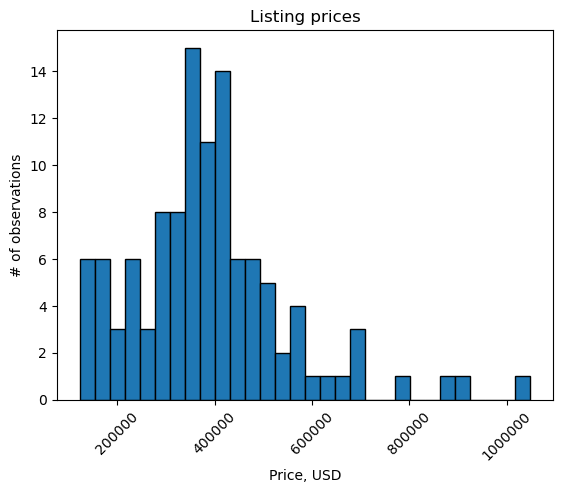

In [ ]:
price = df['list_price']
plt.hist(price.dropna(), bins=30, edgecolor="black")
plt.xlabel("Price, USD")
plt.ylabel("# of observations")
plt.title("Listing prices")
plt.ticklabel_format(style='plain', axis='x')  # disables scientific notation
plt.xticks(rotation=45)
plt.show()

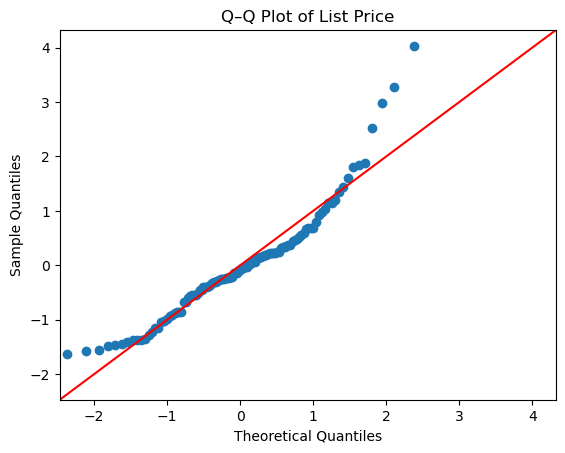

In [ ]:
sm.qqplot(price, line="45", dist=stats.norm, fit=True,)

plt.title("Q–Q Plot of List Price")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

The Q–Q plot shows that the data deviate substantially from the 45 degree line, particularly in the upper tail, indicating noticeable right skewness and non-normality. However, the skewness is not extreme, and with a sufficiently large sample size (n more than 30), the Central Limit Theorem still supports the use of normal-based inference for sample means.

**Exercise 2**

Find the confidence interval for the mean price of a residential property in Twin Cities. Again, assume that the data can be treated as a random sample.

In [ ]:
xbar = np.mean(price)
stats.norm.interval(confidence = 0.95, loc = np.mean(price), scale = stats.sem(price))

(np.float64(358640.7611539299), np.float64(419204.26539474266))

In [ ]:
stats.t.interval(confidence = 0.95, df = nobs-1, loc = np.mean(price), scale = stats.sem(price))

(np.float64(358310.0068056243), np.float64(419535.0197430483))

In [ ]:
print(df['zip'].unique())

[55445 55113 56011 55024 55124 55117]


In [ ]:

# Define groups (left bank = east side; right bank = west side)
LEFT_ZIPS  = {55113, 55117, 55124}
RIGHT_ZIPS = {55445, 55411, 55424}

# Make a safe working copy
d = df.copy()

# Normalize zip to 5-digit ints
d["zip_norm"] = (
    d["zip"]
    .astype(str)
    .str.extract(r"(\d{5})")[0]
    .astype("Int64")  # nullable int
)

# Coerce target metric to numeric and drop NAs
d["list_price_per_sqft"] = pd.to_numeric(d["list_price_per_sqft"], errors="coerce")

# Assign bank label
d["bank"] = np.where(d["zip_norm"].isin(LEFT_ZIPS), "left",
              np.where(d["zip_norm"].isin(RIGHT_ZIPS), "right", pd.NA))

# Keep rows that belong to either group and have the metric
use = d.dropna(subset=["bank", "list_price_per_sqft"])

left_vals  = use.loc[use["bank"] == "left",  "list_price_per_sqft"].astype(float)
right_vals = use.loc[use["bank"] == "right", "list_price_per_sqft"].astype(float)


# Welch's t-test (two-sided)
t_stat, p_val = stats.ttest_ind(left_vals, right_vals, equal_var=False)
print(t_stat, p_val)

-0.052754527092302016 0.9582154822618801
